## Set-up

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    # torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

using device: cuda


### Loading the SAM 2 video predictor

In [3]:
from sam2_minimal.build_sam import build_sam2_video_predictor

sam2_checkpoint = "/scratch2/nico/sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "sam2.1/sam2.1_hiera_l"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device, hydra_overrides_extra=["++model.image_size=448"])
# predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [4]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

#### Select an example video

In [5]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "/scratch2/nico/distillation/dataset/sam2_temp_dir"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# # take a look the first video frame
# frame_idx = 0
# plt.figure(figsize=(9, 6))
# plt.title(f"frame {frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

# # Resize all frames to 224x224
# resized_frames = {}
# target_size = (224, 224)

# for frame_name in frame_names:
#     img = Image.open(os.path.join(video_dir, frame_name))
#     img_resized = img.resize(target_size, Image.LANCZOS)
#     resized_frames[frame_name] = img_resized

# # Display the resized first frame
# plt.figure(figsize=(6, 6))
# plt.title(f"Resized frame {frame_names[0]}")
# plt.imshow(resized_frames[frame_names[0]])
# plt.axis('off')

#### Initialize the inference state

In [6]:
# predictor.image_size == 224
inference_state = predictor.init_state(video_path=video_dir)
print(inference_state["images"][0].shape)

frame loading (JPEG): 100%|██████████| 4/4 [00:00<00:00, 101.30it/s]


torch.Size([3, 448, 448])


In [39]:
# print(predictor.image_size)

### Example 1: Segment & track one object

In [10]:
predictor.reset_state(inference_state)

#### Step 2: Add a second click to refine the prediction

/scratch2/nico/map-anything/sam2_minimal/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2_minimal' (/scratch2/nico/map-anything/sam2_minimal/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


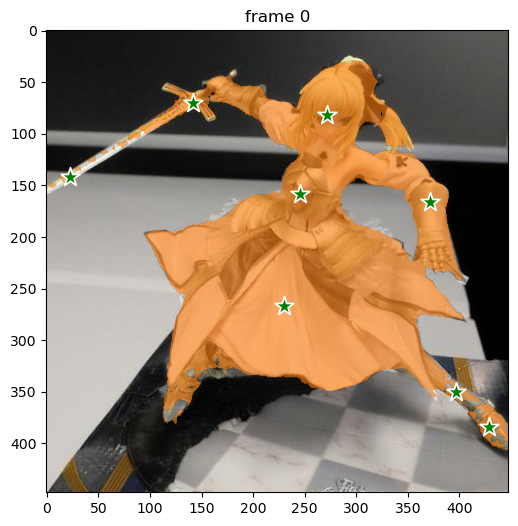

In [7]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd positive click at (x, y) = (250, 220) to refine the mask
# sending all clicks (and their labels) to `add_new_points_or_box`
# points = np.array([[250, 100], [340, 80], [480, 100], [400, 200], [400, 350], [580, 230], [670, 510]], dtype=np.float32)
points = np.array([[272, 82], [142, 70], [245, 158], [230, 267], [372, 166], [22, 142], [429, 384], [397, 350]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
# labels = np.array([1, 1, 1, 1, 1, 1, 1], np.int32)
labels = np.array([1, 1, 1, 1, 1, 1, 1, 1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.open(os.path.join("/scratch2/nico/distillation/dataset/sam2_temp_dir/0.jpg")))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

#### Step 3: Propagate the prompts to get the masklet across the video

propagate in video:   0%|          | 0/4 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 4/4 [00:00<00:00,  8.54it/s]


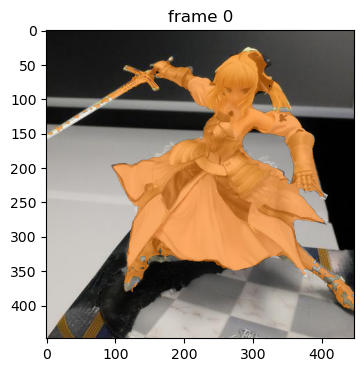

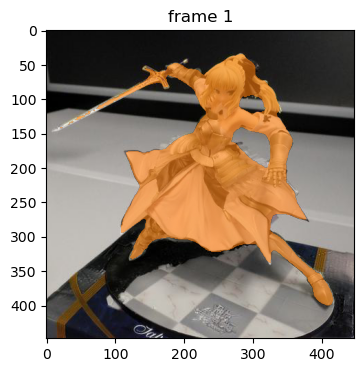

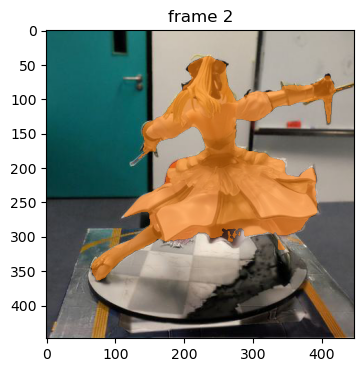

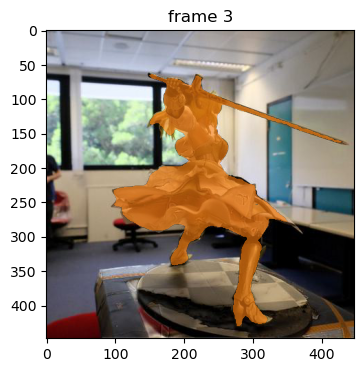

In [8]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 1
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)